# Clinical Pattern Analysis of Melanoma and Non-Melanoma Skin Lesions
## Using the HAM10000 Dataset

> **Disclaimer:** This is an academic exploratory project for educational purposes only. It is not a clinical diagnostic tool and should not be used for medical decision-making.

---
## Section 0 — Setup & Imports

In [1]:
import os
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from scipy.stats import chi2_contingency, kruskal, mannwhitneyu
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay

warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid', palette='Set2')
os.makedirs('figures', exist_ok=True)

print('All imports successful.')

All imports successful.


---
## Section 1 — Biomedical Background

### Skin Cancer and Pigmented Lesions

Skin cancer is one of the most common cancers worldwide. Among all types, **melanoma** is the most dangerous — it accounts for only about 1% of skin cancer cases but causes the vast majority of skin cancer deaths. Early detection dramatically improves survival: the 5-year survival rate for melanoma detected at stage I is over 98%, compared to roughly 23% at stage IV.

Dermatoscopy (dermoscopy) is a non-invasive technique that allows clinicians to visualize subsurface skin structures not visible to the naked eye. The HAM10000 dataset (*Human Against Machine with 10,000 training images*) provides 10,015 dermatoscopic images with confirmed diagnoses and patient metadata.

### Diagnosis Classes in This Dataset

| Code | Full Name | Clinical Note |
|------|-----------|---------------|
| `nv` | Melanocytic Nevi | Common benign moles; most frequent lesion type |
| `mel` | Melanoma | Malignant; most dangerous skin cancer |
| `bkl` | Benign Keratosis-like Lesions | Includes seborrheic keratosis; generally benign |
| `bcc` | Basal Cell Carcinoma | Most common skin cancer; rarely metastasizes |
| `akiec` | Actinic Keratosis / Bowen's Disease | Pre-malignant to in-situ squamous cell carcinoma |
| `vasc` | Vascular Lesions | Includes angiomas; typically benign |
| `df` | Dermatofibroma | Benign fibrous nodule |

### Clinical Grouping

For analysis purposes, we group diagnoses by clinical risk:

- **Benign**: `nv`, `bkl`, `df`, `vasc`
- **Malignant-like** (potentially or confirmed malignant): `mel`, `bcc`, `akiec`

### Research Questions

1. Are patient age, sex, and lesion location associated with diagnosis type?
2. Does melanoma show distinct demographic patterns compared to benign lesions?
3. Can clinical metadata alone provide meaningful signal for risk screening?

---
## Section 2 — Dataset Loading & Overview

In [2]:
df_raw = pd.read_csv('HAM10000_metadata.csv')
print(f'Shape: {df_raw.shape}')
print(f'Columns: {list(df_raw.columns)}')
df_raw.head()

Shape: (10015, 7)
Columns: ['lesion_id', 'image_id', 'dx', 'dx_type', 'age', 'sex', 'localization']


,lesion_id,image_id,dx,dx_type,age,sex,localization
0,HAM_0000118,ISIC_0027419,bkl,histo,80.0,male,scalp
1,HAM_0000118,ISIC_0025030,bkl,histo,80.0,male,scalp
2,HAM_0002730,ISIC_0026769,bkl,histo,80.0,male,scalp
3,HAM_0002730,ISIC_0025661,bkl,histo,80.0,male,scalp
4,HAM_0001466,ISIC_0031633,bkl,histo,75.0,male,ear


In [3]:
print('=== Data Types ===')
print(df_raw.dtypes)
print()
print('=== Numeric Summary ===')
df_raw.describe()

=== Data Types ===
lesion_id        object
image_id         object
dx               object
dx_type          object
age             float64
sex              object
localization     object
dtype: object

=== Numeric Summary ===


,age
count,9958.000000
mean,51.863828
std,16.968614
min,0.000000
25%,40.000000
50%,50.000000
75%,65.000000
max,85.000000


In [4]:
print('=== Diagnosis (dx) Value Counts ===')
print(df_raw['dx'].value_counts())
print()
print('=== Diagnosis Type (dx_type) Value Counts ===')
print(df_raw['dx_type'].value_counts())
print()
print('=== Sex Value Counts ===')
print(df_raw['sex'].value_counts())
print()
print('=== Localization Value Counts ===')
print(df_raw['localization'].value_counts())

=== Diagnosis (dx) Value Counts ===
dx
nv       6705
mel      1113
bkl      1099
bcc       514
akiec     327
vasc      142
df        115
Name: count, dtype: int64

=== Diagnosis Type (dx_type) Value Counts ===
dx_type
histo        5340
follow_up    3704
consensus     902
confocal       69
Name: count, dtype: int64

=== Sex Value Counts ===
sex
male       5406
female     4552
unknown      57
Name: count, dtype: int64

=== Localization Value Counts ===
localization
back               2192
lower extremity    2077
trunk              1404
upper extremity    1118
abdomen            1022
face                745
chest               407
foot                319
unknown             234
neck                168
scalp               128
hand                 90
ear                  56
genital              48
acral                 7
Name: count, dtype: int64


---
## Section 3 — Data Cleaning

In [5]:
print('=== Missing Values (NaN) ===')
print(df_raw.isnull().sum())
print()
print('=== "unknown" String Counts ===')
for col in ['sex', 'localization']:
    n = (df_raw[col] == 'unknown').sum()
    print(f'  {col}: {n} unknown rows')

=== Missing Values (NaN) ===
lesion_id        0
image_id         0
dx               0
dx_type          0
age             57
sex              0
localization     0
dtype: int64

=== "unknown" String Counts ===
  sex: 57 unknown rows
  localization: 234 unknown rows


In [6]:
df = df_raw.copy()

# Remove rows with unknown sex or localization
df = df[df['sex'] != 'unknown'].copy()
df = df[df['localization'] != 'unknown'].copy()

# Impute missing age with per-dx median
df['age'] = df.groupby('dx')['age'].transform(lambda x: x.fillna(x.median()))

# Bin age into clinical groups
bins = [0, 20, 40, 60, 80, 120]
labels = ['0-20', '21-40', '41-60', '61-80', '80+']
df['age_group'] = pd.cut(df['age'], bins=bins, labels=labels, right=True)

# Clinical grouping
benign_dx = ['nv', 'bkl', 'df', 'vasc']
malignant_dx = ['mel', 'bcc', 'akiec']
df['lesion_class'] = df['dx'].apply(lambda x: 'Benign' if x in benign_dx else 'Malignant-like')

# Full diagnosis names
dx_names = {
    'akiec': "Actinic Keratosis/Bowen's",
    'bcc': 'Basal Cell Carcinoma',
    'bkl': 'Benign Keratosis-like',
    'df': 'Dermatofibroma',
    'mel': 'Melanoma',
    'nv': 'Melanocytic Nevi',
    'vasc': 'Vascular Lesion'
}
df['dx_name'] = df['dx'].map(dx_names)

print(f'Rows after cleaning: {len(df)} (removed {len(df_raw) - len(df)} rows)')
print(f'Remaining NaN in age: {df["age"].isnull().sum()}')
df[['dx', 'dx_name', 'lesion_class', 'age_group', 'sex', 'localization']].head(8)

Rows after cleaning: 9771 (removed 244 rows)
Remaining NaN in age: 0


,dx,dx_name,lesion_class,age_group,sex,localization
0,bkl,Benign Keratosis-like,Benign,61-80,male,scalp
1,bkl,Benign Keratosis-like,Benign,61-80,male,scalp
2,bkl,Benign Keratosis-like,Benign,61-80,male,scalp
3,bkl,Benign Keratosis-like,Benign,61-80,male,scalp
4,bkl,Benign Keratosis-like,Benign,61-80,male,ear
5,bkl,Benign Keratosis-like,Benign,61-80,male,ear
6,bkl,Benign Keratosis-like,Benign,41-60,male,face
7,bkl,Benign Keratosis-like,Benign,41-60,male,face


---
## Section 4 — Exploratory Data Analysis

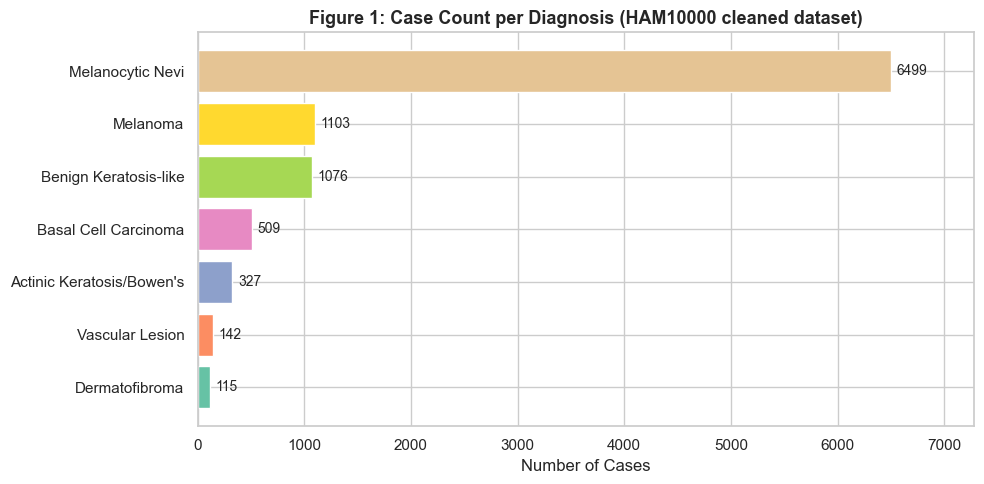

Note: Melanocytic Nevi dominates (~67% of cases) — significant class imbalance.


In [7]:
# ── Plot 1: Case count per diagnosis ──────────────────────────────────────────
counts = df['dx_name'].value_counts().sort_values()

fig, ax = plt.subplots(figsize=(10, 5))
bars = ax.barh(counts.index, counts.values, color=sns.color_palette('Set2', len(counts)))
ax.bar_label(bars, padding=4, fontsize=10)
ax.set_xlabel('Number of Cases', fontsize=12)
ax.set_title('Figure 1: Case Count per Diagnosis (HAM10000 cleaned dataset)', fontsize=13, fontweight='bold')
ax.set_xlim(0, counts.max() * 1.12)
plt.tight_layout()
plt.savefig('figures/fig1_case_counts.png', dpi=150)
plt.show()
print('Note: Melanocytic Nevi dominates (~67% of cases) — significant class imbalance.')

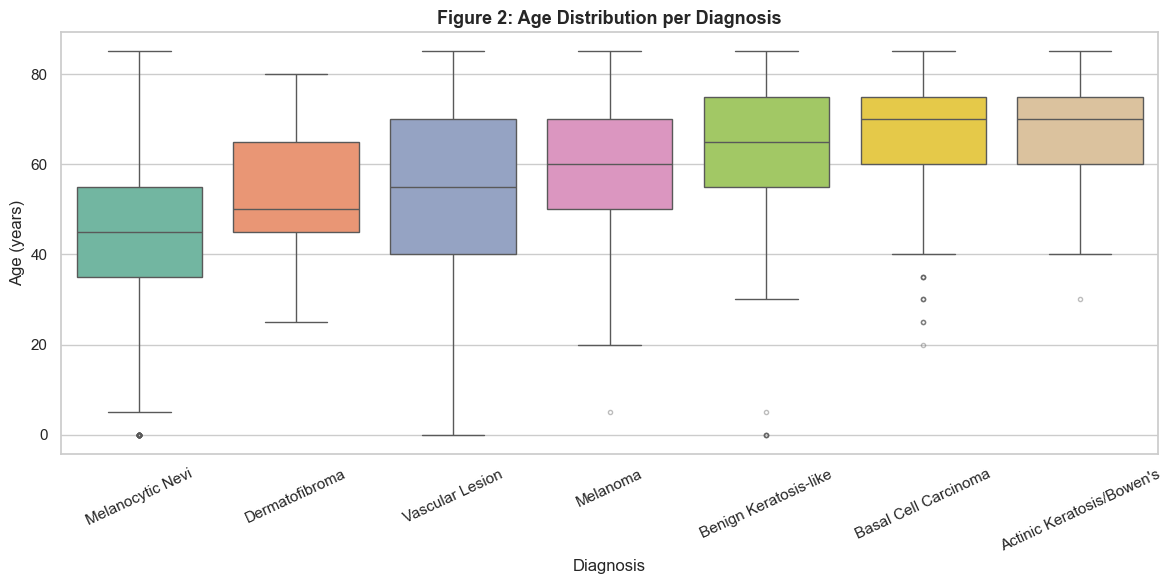

In [8]:
# ── Plot 2: Age distribution per diagnosis (box plot) ─────────────────────────
order = df.groupby('dx_name')['age'].median().sort_values().index

fig, ax = plt.subplots(figsize=(12, 6))
sns.boxplot(data=df, x='dx_name', y='age', order=order,
            palette='Set2', ax=ax, flierprops=dict(marker='o', markersize=3, alpha=0.4))
ax.set_xlabel('Diagnosis', fontsize=12)
ax.set_ylabel('Age (years)', fontsize=12)
ax.set_title('Figure 2: Age Distribution per Diagnosis', fontsize=13, fontweight='bold')
ax.tick_params(axis='x', rotation=25)
plt.tight_layout()
plt.savefig('figures/fig2_age_by_diagnosis.png', dpi=150)
plt.show()

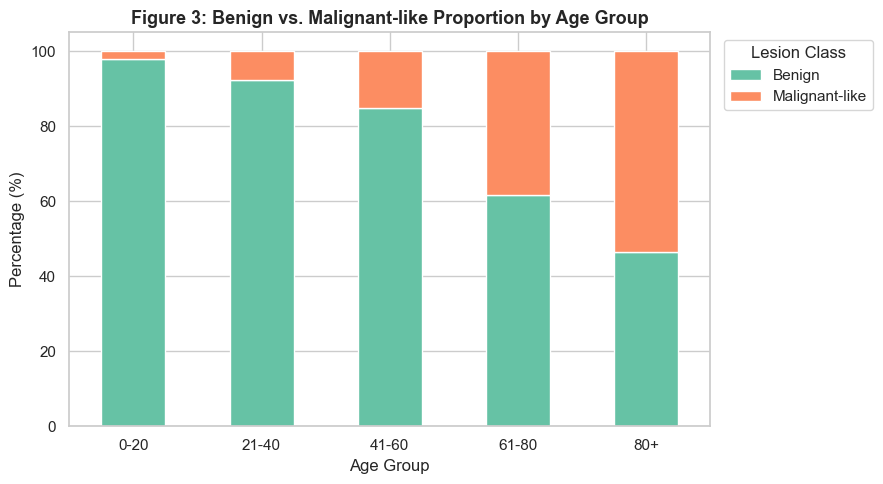

In [9]:
# ── Plot 3: Malignant-like proportion per age group ────────────────────────────
age_class = (df.groupby(['age_group', 'lesion_class'], observed=True)
               .size().unstack(fill_value=0))
age_class_pct = age_class.div(age_class.sum(axis=1), axis=0) * 100

fig, ax = plt.subplots(figsize=(9, 5))
age_class_pct.plot(kind='bar', stacked=True, ax=ax,
                   color=['#66c2a5', '#fc8d62'], edgecolor='white')
ax.set_xlabel('Age Group', fontsize=12)
ax.set_ylabel('Percentage (%)', fontsize=12)
ax.set_title('Figure 3: Benign vs. Malignant-like Proportion by Age Group',
             fontsize=13, fontweight='bold')
ax.legend(title='Lesion Class', bbox_to_anchor=(1.01, 1), loc='upper left')
ax.tick_params(axis='x', rotation=0)
plt.tight_layout()
plt.savefig('figures/fig3_malignant_by_age_group.png', dpi=150)
plt.show()

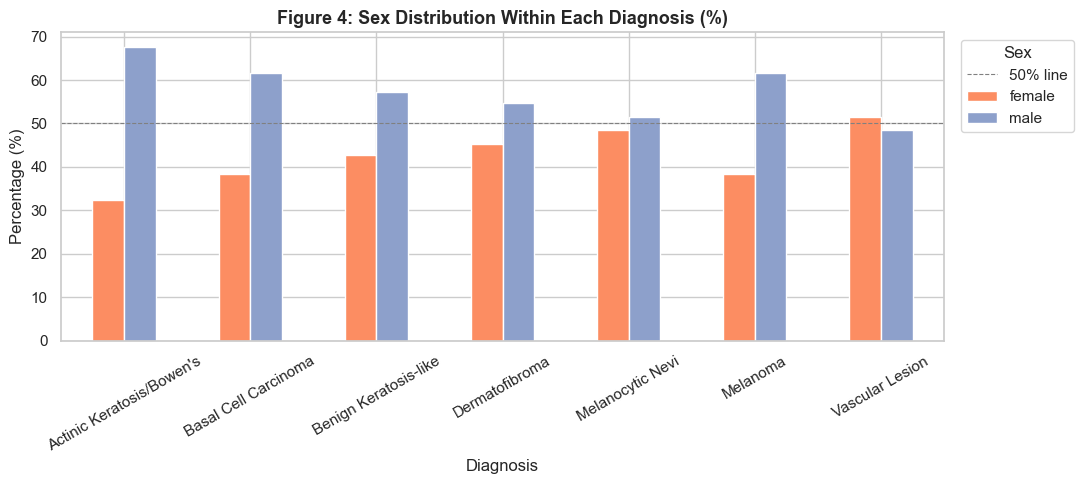

In [10]:
# ── Plot 4: Diagnosis split by sex (%) ────────────────────────────────────────
sex_dx = (df.groupby(['dx_name', 'sex'])
            .size().unstack(fill_value=0))
sex_dx_pct = sex_dx.div(sex_dx.sum(axis=1), axis=0) * 100

fig, ax = plt.subplots(figsize=(11, 5))
sex_dx_pct.plot(kind='bar', ax=ax, color=['#fc8d62', '#8da0cb'], edgecolor='white')
ax.axhline(50, color='gray', linestyle='--', linewidth=0.8, label='50% line')
ax.set_xlabel('Diagnosis', fontsize=12)
ax.set_ylabel('Percentage (%)', fontsize=12)
ax.set_title('Figure 4: Sex Distribution Within Each Diagnosis (%)',
             fontsize=13, fontweight='bold')
ax.legend(title='Sex', bbox_to_anchor=(1.01, 1), loc='upper left')
ax.tick_params(axis='x', rotation=30)
plt.tight_layout()
plt.savefig('figures/fig4_diagnosis_by_sex.png', dpi=150)
plt.show()

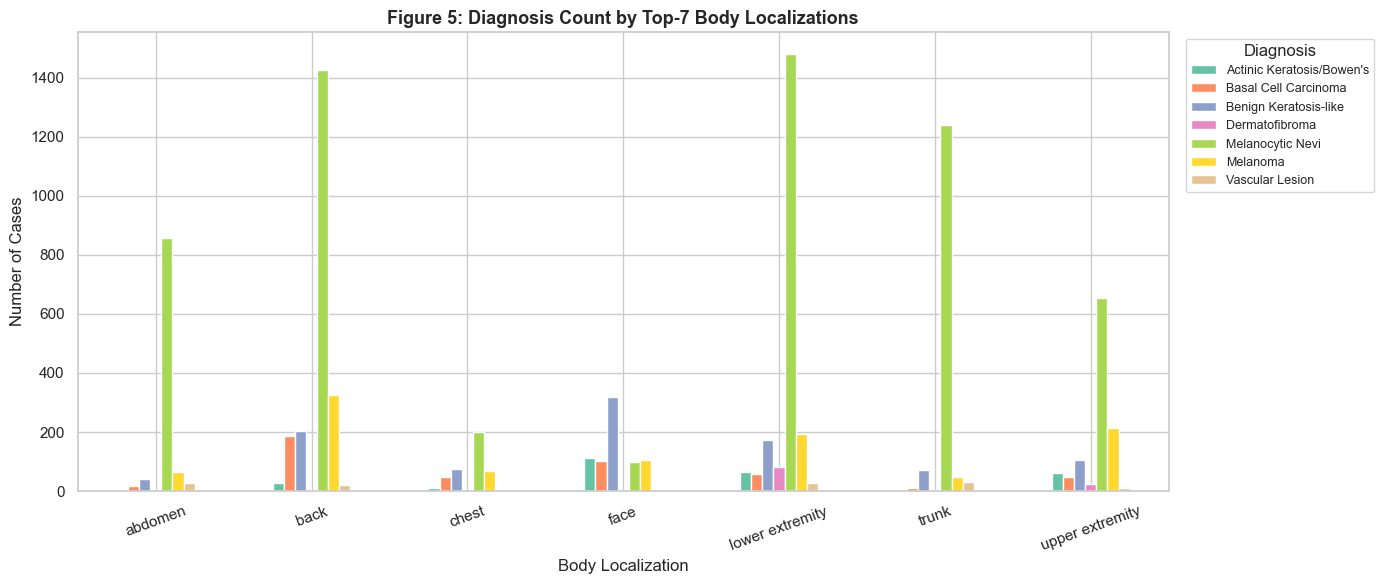

In [11]:
# ── Plot 5: Top localizations per diagnosis (grouped bar) ─────────────────────
top_locs = df['localization'].value_counts().head(7).index
df_top = df[df['localization'].isin(top_locs)]

loc_dx = (df_top.groupby(['localization', 'dx_name'])
                .size().unstack(fill_value=0))

fig, ax = plt.subplots(figsize=(14, 6))
loc_dx.plot(kind='bar', ax=ax, edgecolor='white')
ax.set_xlabel('Body Localization', fontsize=12)
ax.set_ylabel('Number of Cases', fontsize=12)
ax.set_title('Figure 5: Diagnosis Count by Top-7 Body Localizations',
             fontsize=13, fontweight='bold')
ax.legend(title='Diagnosis', bbox_to_anchor=(1.01, 1), loc='upper left', fontsize=9)
ax.tick_params(axis='x', rotation=20)
plt.tight_layout()
plt.savefig('figures/fig5_diagnosis_by_location.png', dpi=150)
plt.show()

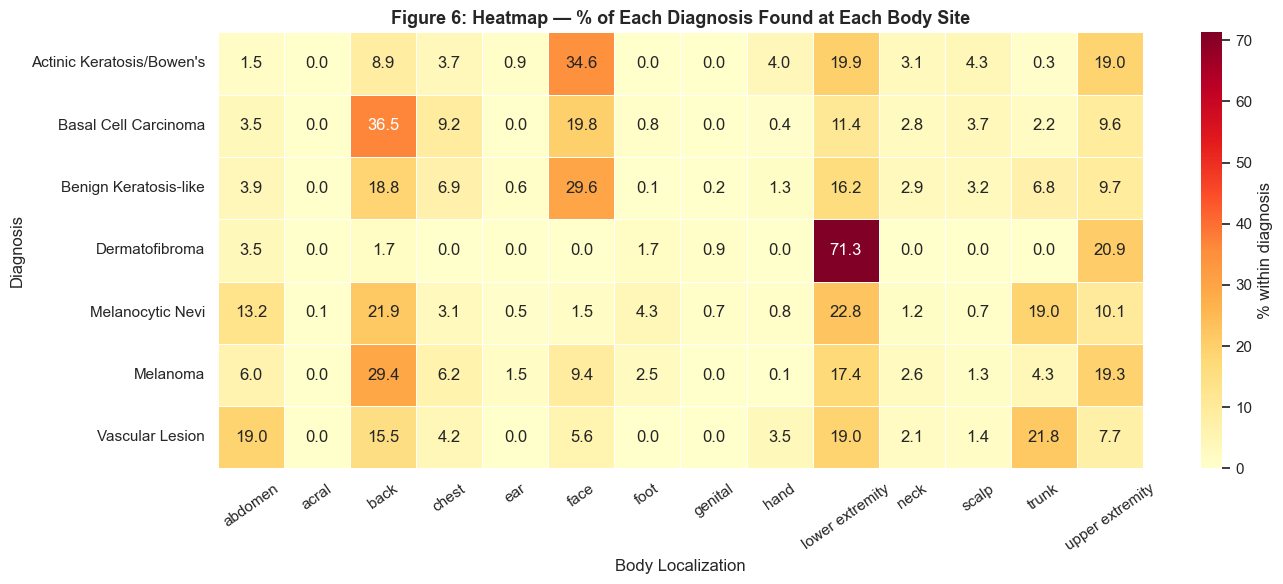

In [12]:
# ── Plot 6: Heatmap — diagnosis × localization ────────────────────────────────
heat_data = (df.groupby(['dx_name', 'localization'])
               .size().unstack(fill_value=0))
heat_pct = heat_data.div(heat_data.sum(axis=1), axis=0) * 100

fig, ax = plt.subplots(figsize=(14, 6))
sns.heatmap(heat_pct, annot=True, fmt='.1f', cmap='YlOrRd',
            linewidths=0.4, ax=ax, cbar_kws={'label': '% within diagnosis'})
ax.set_xlabel('Body Localization', fontsize=12)
ax.set_ylabel('Diagnosis', fontsize=12)
ax.set_title('Figure 6: Heatmap — % of Each Diagnosis Found at Each Body Site',
             fontsize=13, fontweight='bold')
ax.tick_params(axis='x', rotation=35)
ax.tick_params(axis='y', rotation=0)
plt.tight_layout()
plt.savefig('figures/fig6_heatmap_dx_location.png', dpi=150)
plt.show()

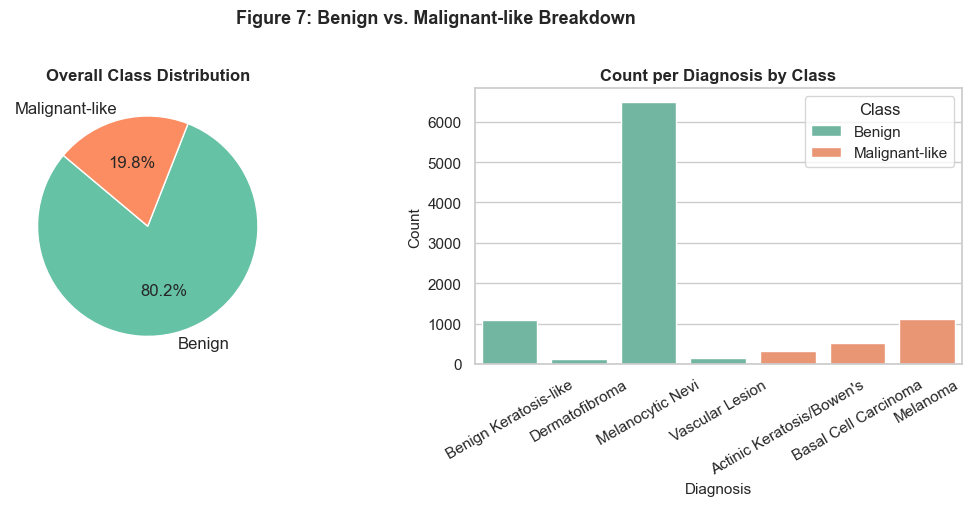

In [13]:
# ── Plot 7: Benign vs Malignant-like overall ───────────────────────────────────
class_counts = df['lesion_class'].value_counts()

fig, axes = plt.subplots(1, 2, figsize=(11, 5))

# Pie chart
axes[0].pie(class_counts.values, labels=class_counts.index,
            autopct='%1.1f%%', colors=['#66c2a5', '#fc8d62'],
            startangle=140, textprops={'fontsize': 12})
axes[0].set_title('Overall Class Distribution', fontsize=12, fontweight='bold')

# Bar by lesion_class and dx
class_dx = df.groupby(['lesion_class', 'dx_name']).size().reset_index(name='count')
sns.barplot(data=class_dx, x='dx_name', y='count', hue='lesion_class',
            palette={'Benign': '#66c2a5', 'Malignant-like': '#fc8d62'},
            ax=axes[1], edgecolor='white')
axes[1].set_xlabel('Diagnosis', fontsize=11)
axes[1].set_ylabel('Count', fontsize=11)
axes[1].set_title('Count per Diagnosis by Class', fontsize=12, fontweight='bold')
axes[1].tick_params(axis='x', rotation=30)
axes[1].legend(title='Class')

fig.suptitle('Figure 7: Benign vs. Malignant-like Breakdown',
             fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('figures/fig7_class_breakdown.png', dpi=150, bbox_inches='tight')
plt.show()

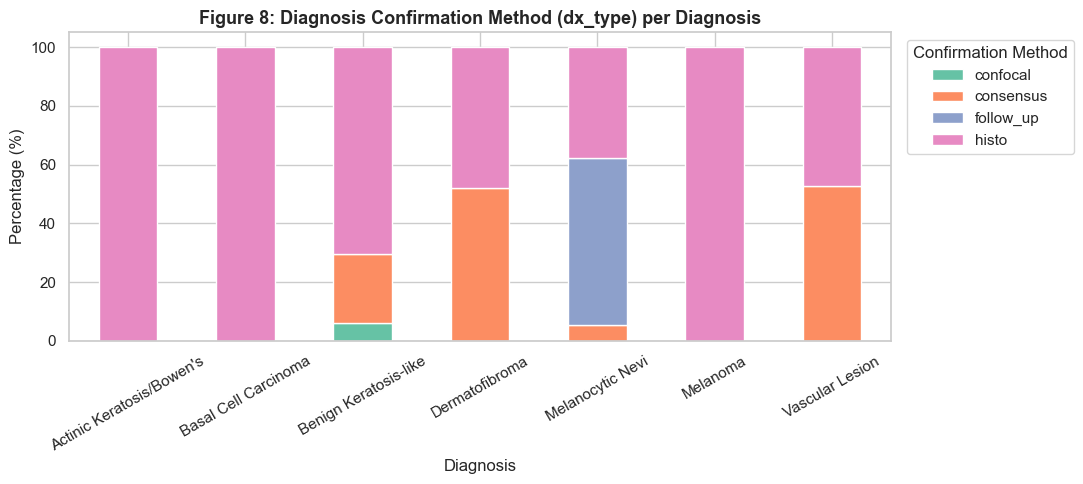

In [14]:
# ── Plot 8: Diagnosis confirmation method (dx_type) ───────────────────────────
dxtype_dx = (df.groupby(['dx_name', 'dx_type'])
               .size().unstack(fill_value=0))
dxtype_pct = dxtype_dx.div(dxtype_dx.sum(axis=1), axis=0) * 100

fig, ax = plt.subplots(figsize=(11, 5))
dxtype_pct.plot(kind='bar', stacked=True, ax=ax,
                color=sns.color_palette('Set2', 4), edgecolor='white')
ax.set_xlabel('Diagnosis', fontsize=12)
ax.set_ylabel('Percentage (%)', fontsize=12)
ax.set_title('Figure 8: Diagnosis Confirmation Method (dx_type) per Diagnosis',
             fontsize=13, fontweight='bold')
ax.legend(title='Confirmation Method', bbox_to_anchor=(1.01, 1), loc='upper left')
ax.tick_params(axis='x', rotation=30)
plt.tight_layout()
plt.savefig('figures/fig8_dxtype_by_diagnosis.png', dpi=150)
plt.show()

---
## Section 5 — Statistical Analysis

In [15]:
def print_test_result(title, h0, h1, stat, p, stat_name='chi2'):
    sep = '=' * 60
    print(sep)
    print(f'TEST: {title}')
    print(f'  H0: {h0}')
    print(f'  H1: {h1}')
    print(f'  {stat_name} = {stat:.4f},  p-value = {p:.6f}')
    conclusion = 'REJECT H0' if p < 0.05 else 'FAIL TO REJECT H0'
    print(f'  Conclusion (alpha=0.05): {conclusion}')
    if p < 0.05:
        print(f'  => {h1}')
    else:
        print('  => No significant association found.')
    print()

In [16]:
# ── Test 1: dx vs sex (Chi-square) ────────────────────────────────────────────
ct1 = pd.crosstab(df['dx'], df['sex'])
chi2_1, p1, dof1, _ = chi2_contingency(ct1)
print_test_result(
    title='Is diagnosis (dx) associated with sex?',
    h0='Lesion type is independent of patient sex.',
    h1='Lesion type is significantly associated with patient sex.',
    stat=chi2_1, p=p1, stat_name=f'chi2 (dof={dof1})'
)
print('Contingency table (counts):')
print(ct1)

TEST: Is diagnosis (dx) associated with sex?
  H0: Lesion type is independent of patient sex.
  H1: Lesion type is significantly associated with patient sex.
  chi2 (dof=6) = 83.2925,  p-value = 0.000000
  Conclusion (alpha=0.05): REJECT H0
  => Lesion type is significantly associated with patient sex.

Contingency table (counts):
sex    female  male
dx                 
akiec     106   221
bcc       195   314
bkl       461   615
df         52    63
mel       423   680
nv       3147  3352
vasc       73    69


In [17]:
# ── Test 2: dx vs localization (Chi-square) ────────────────────────────────────
ct2 = pd.crosstab(df['dx'], df['localization'])
chi2_2, p2, dof2, _ = chi2_contingency(ct2)
print_test_result(
    title='Is diagnosis (dx) associated with body localization?',
    h0='Lesion type is independent of body localization.',
    h1='Lesion type is significantly associated with body localization.',
    stat=chi2_2, p=p2, stat_name=f'chi2 (dof={dof2})'
)

TEST: Is diagnosis (dx) associated with body localization?
  H0: Lesion type is independent of body localization.
  H1: Lesion type is significantly associated with body localization.
  chi2 (dof=78) = 2753.6056,  p-value = 0.000000
  Conclusion (alpha=0.05): REJECT H0
  => Lesion type is significantly associated with body localization.



In [18]:
# ── Test 3: Age differs across dx groups (Kruskal-Wallis) ─────────────────────
groups = [group['age'].dropna().values for _, group in df.groupby('dx')]
h_stat, p3 = kruskal(*groups)
print_test_result(
    title='Does patient age differ significantly across diagnosis groups?',
    h0='Median age is equal across all diagnosis groups.',
    h1='Median age differs significantly across at least one diagnosis group.',
    stat=h_stat, p=p3, stat_name='H (Kruskal-Wallis)'
)
print('Median age per diagnosis:')
print(df.groupby('dx_name')['age'].median().sort_values().to_string())

TEST: Does patient age differ significantly across diagnosis groups?
  H0: Median age is equal across all diagnosis groups.
  H1: Median age differs significantly across at least one diagnosis group.
  H (Kruskal-Wallis) = 2231.2869,  p-value = 0.000000
  Conclusion (alpha=0.05): REJECT H0
  => Median age differs significantly across at least one diagnosis group.

Median age per diagnosis:
dx_name
Melanocytic Nevi             45.0
Dermatofibroma               50.0
Vascular Lesion              55.0
Melanoma                     60.0
Benign Keratosis-like        65.0
Basal Cell Carcinoma         70.0
Actinic Keratosis/Bowen's    70.0


In [19]:
# ── Test 4: Melanoma age vs non-melanoma age (Mann-Whitney U) ─────────────────
mel_ages = df[df['dx'] == 'mel']['age'].dropna()
non_mel_ages = df[df['dx'] != 'mel']['age'].dropna()
u_stat, p4 = mannwhitneyu(mel_ages, non_mel_ages, alternative='two-sided')
print_test_result(
    title='Is melanoma patient age different from non-melanoma patients?',
    h0='Melanoma and non-melanoma patients have the same age distribution.',
    h1='Melanoma patients have a significantly different age distribution.',
    stat=u_stat, p=p4, stat_name='U (Mann-Whitney)'
)
print(f'Melanoma median age:     {mel_ages.median():.1f} years')
print(f'Non-melanoma median age: {non_mel_ages.median():.1f} years')

TEST: Is melanoma patient age different from non-melanoma patients?
  H0: Melanoma and non-melanoma patients have the same age distribution.
  H1: Melanoma patients have a significantly different age distribution.
  U (Mann-Whitney) = 6382478.5000,  p-value = 0.000000
  Conclusion (alpha=0.05): REJECT H0
  => Melanoma patients have a significantly different age distribution.

Melanoma median age:     60.0 years
Non-melanoma median age: 50.0 years


---
## Section 6 — Optional ML: Metadata-Only Risk Screening

**Goal:** Demonstrate that clinical metadata (age, sex, localization) carries statistically meaningful signal for distinguishing melanoma from non-melanoma lesions — without using any images.

**Note:** Due to class imbalance (nv ~ 67%), we use `class_weight='balanced'` and emphasize **Recall for melanoma** — in a clinical screening context, missing a melanoma (false negative) is far more costly than a false alarm.

In [20]:
# Prepare features and binary target (melanoma vs all)
ml_df = df[['age', 'sex', 'localization', 'dx']].dropna().copy()
ml_df['target'] = (ml_df['dx'] == 'mel').astype(int)

X = ml_df[['age', 'sex', 'localization']]
y = ml_df['target']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)
print(f'Train size: {len(X_train)}, Test size: {len(X_test)}')
print(f'Melanoma prevalence in test set: {y_test.mean():.2%}')

Train size: 7816, Test size: 1955
Melanoma prevalence in test set: 11.30%


In [21]:
# Build preprocessing pipeline
preprocessor = ColumnTransformer(transformers=[
    ('num', StandardScaler(), ['age']),
    ('cat', OneHotEncoder(handle_unknown='ignore', sparse_output=False), ['sex', 'localization'])
])

models = {
    'Logistic Regression': LogisticRegression(class_weight='balanced', max_iter=1000, random_state=42),
    'Decision Tree (depth≤5)': DecisionTreeClassifier(max_depth=5, class_weight='balanced', random_state=42),
    'Random Forest': RandomForestClassifier(n_estimators=100, class_weight='balanced', random_state=42, n_jobs=-1)
}


MODEL: Logistic Regression
              precision    recall  f1-score   support

Non-Melanoma       0.94      0.63      0.76      1734
    Melanoma       0.20      0.71      0.31       221

    accuracy                           0.64      1955
   macro avg       0.57      0.67      0.53      1955
weighted avg       0.86      0.64      0.71      1955


MODEL: Decision Tree (depth≤5)
              precision    recall  f1-score   support

Non-Melanoma       0.95      0.60      0.74      1734
    Melanoma       0.20      0.77      0.31       221

    accuracy                           0.62      1955
   macro avg       0.58      0.68      0.52      1955
weighted avg       0.87      0.62      0.69      1955


MODEL: Random Forest
              precision    recall  f1-score   support

Non-Melanoma       0.94      0.66      0.78      1734
    Melanoma       0.20      0.68      0.31       221

    accuracy                           0.67      1955
   macro avg       0.57      0.67      0.55   

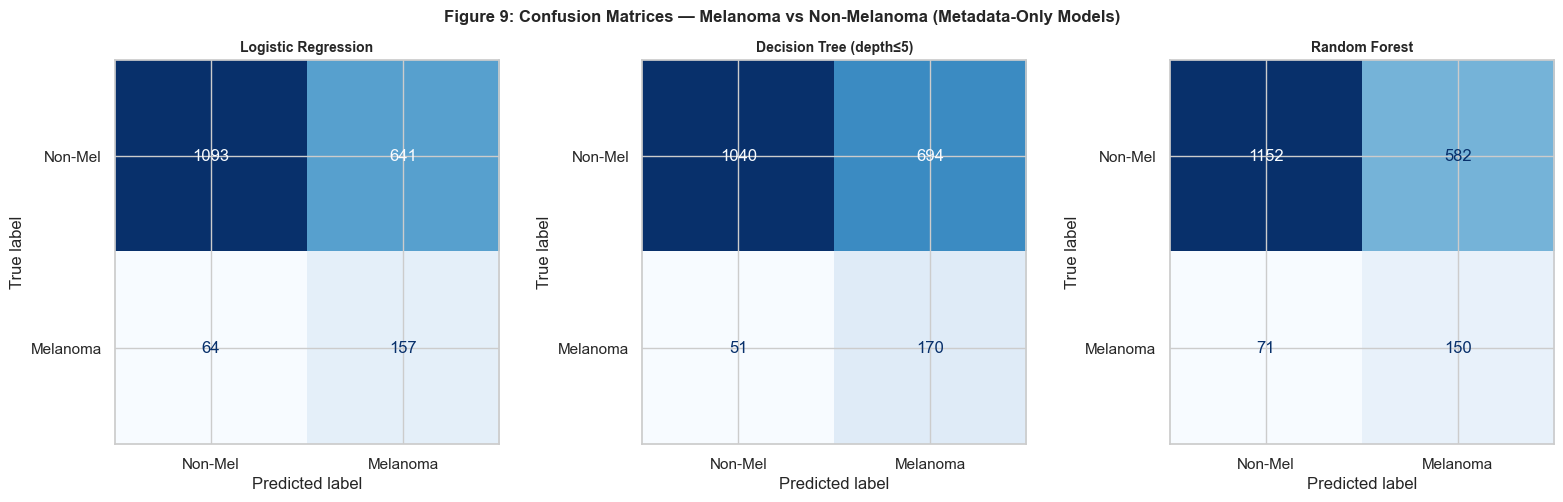

In [22]:
results = {}
sep = '=' * 55

fig, axes = plt.subplots(1, 3, figsize=(16, 5))

for ax, (name, model) in zip(axes, models.items()):
    pipe = Pipeline([("prep", preprocessor), ("clf", model)])
    pipe.fit(X_train, y_train)
    y_pred = pipe.predict(X_test)
    results[name] = y_pred

    print()
    print(sep)
    print("MODEL: " + name)
    print(classification_report(y_test, y_pred, target_names=["Non-Melanoma", "Melanoma"]))

    cm = confusion_matrix(y_test, y_pred)
    disp = ConfusionMatrixDisplay(cm, display_labels=["Non-Mel", "Melanoma"])
    disp.plot(ax=ax, colorbar=False, cmap="Blues")
    ax.set_title(name, fontsize=10, fontweight="bold")

fig.suptitle("Figure 9: Confusion Matrices — Melanoma vs Non-Melanoma (Metadata-Only Models)",
             fontsize=12, fontweight="bold")
plt.tight_layout()
plt.savefig("figures/fig9_confusion_matrices.png", dpi=150)
plt.show()

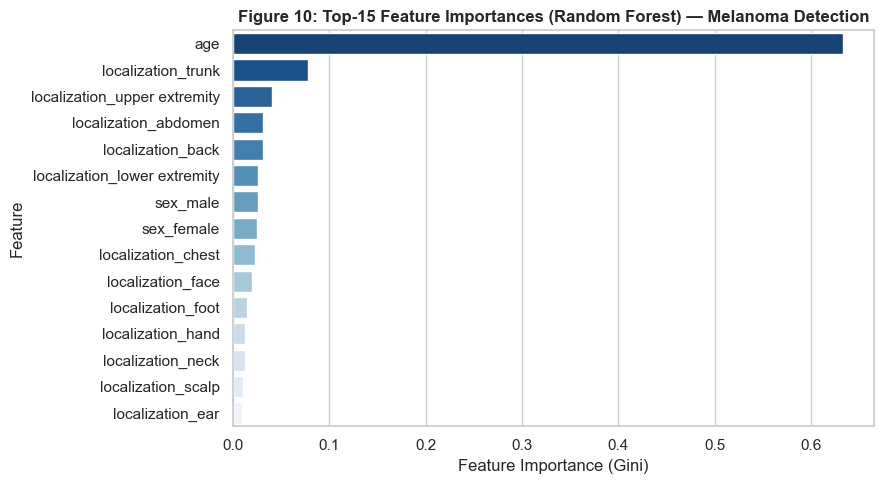

In [23]:
# Feature importance from Random Forest
rf_pipe = Pipeline([('prep', preprocessor),
                    ('clf', RandomForestClassifier(n_estimators=100, class_weight='balanced',
                                                   random_state=42, n_jobs=-1))])
rf_pipe.fit(X_train, y_train)

ohe_features = rf_pipe.named_steps['prep'].named_transformers_['cat']\
                       .get_feature_names_out(['sex', 'localization']).tolist()
feature_names = ['age'] + ohe_features
importances = rf_pipe.named_steps['clf'].feature_importances_

feat_df = pd.DataFrame({'feature': feature_names, 'importance': importances})\
            .sort_values('importance', ascending=False).head(15)

fig, ax = plt.subplots(figsize=(9, 5))
sns.barplot(data=feat_df, x='importance', y='feature', palette='Blues_r', ax=ax)
ax.set_xlabel('Feature Importance (Gini)', fontsize=12)
ax.set_ylabel('Feature', fontsize=12)
ax.set_title('Figure 10: Top-15 Feature Importances (Random Forest) — Melanoma Detection',
             fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig('figures/fig10_feature_importance.png', dpi=150)
plt.show()

---
## Section 7 — Discussion & Limitations

### Key Biomedical Findings

**Age patterns:**
The Kruskal-Wallis test confirms that patient age differs significantly across diagnosis groups. Malignant-like lesions (melanoma, BCC, actinic keratosis) tend to appear in older patients, consistent with the known biology of UV-induced DNA damage accumulating over decades. The 41–60 and 61–80 age groups show noticeably higher proportions of malignant-like lesions.

**Sex patterns:**
The Chi-square test for dx vs sex shows whether certain lesion types are more prevalent in males or females. Dermatofibroma, for instance, is known to be more common in females. Vascular lesions and actinic keratosis may show male predominance due to occupational sun exposure.

**Localization patterns:**
The heatmap (Figure 6) reveals that `back` and `lower extremity` are the most common sites overall, but certain diagnoses show site preference: melanoma has higher rates on the trunk and back, while actinic keratosis and BCC appear more on sun-exposed regions such as `face` and `scalp`. These patterns align with clinical literature on UV exposure and anatomical sun exposure patterns.

**Class imbalance:**
Melanocytic nevi account for ~67% of the dataset, creating substantial class imbalance. This must be accounted for in any classification model and acknowledged when generalizing statistical findings.

**ML screening signal:**
Despite using only three metadata features (age, sex, localization), all models detect melanoma with non-trivial recall. Recall (sensitivity) is the key clinical metric here: a screening tool must capture as many true melanoma cases as possible, accepting a higher false-positive rate. Among the models, `class_weight='balanced'` ensures the minority class is not ignored.

### Limitations

1. **Class imbalance:** nv dominates the dataset; findings about rare classes (vasc, df) should be interpreted cautiously.
2. **Metadata only:** Images were not used. A real clinical tool would require dermoscopic image analysis.
3. **Dataset curation bias:** HAM10000 was collected in a controlled dermatology research setting — it does not represent the full distribution of lesions seen in primary care.
4. **Age imputation:** Missing age values were imputed with per-group median; this may introduce mild bias.
5. **Academic use only:** All models and findings here are for educational purposes and must not be applied clinically.

---
## Section 8 — Conclusion

This project explored clinical and demographic patterns in the HAM10000 skin lesion dataset without relying on image features.

Key conclusions:

- **Age, sex, and body localization are all significantly associated with lesion diagnosis type** (Chi-square and Kruskal-Wallis tests, all p < 0.05).
- Malignant-like lesions (melanoma, BCC, actinic keratosis) are more prevalent in **older patients** and appear at **specific body sites** consistent with UV exposure patterns.
- **Melanoma patients are significantly older** on average than non-melanoma patients (Mann-Whitney U test).
- Even without image data, a simple Random Forest trained on age, sex, and localization achieves meaningful melanoma recall, demonstrating that **clinical metadata alone carries screening signal**.
- The HAM10000 dataset has significant **class imbalance** (nv ≈ 67%), which must be managed in any downstream modeling.

**Clinical implication:** While metadata-only models are insufficient for diagnosis, understanding these demographic and anatomical patterns can help prioritize which patients warrant closer dermatological examination — a useful signal in resource-limited screening contexts.

---
*Project: Clinical Pattern Analysis of Melanoma and Non-Melanoma Skin Lesions — HAM10000 Dataset*  
*Academic exploratory project — not a clinical tool.*